In [1]:
from rabtracks import *
sns.set_context("paper")

/tmp/ipykernel_900/1807153089.py:46: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")


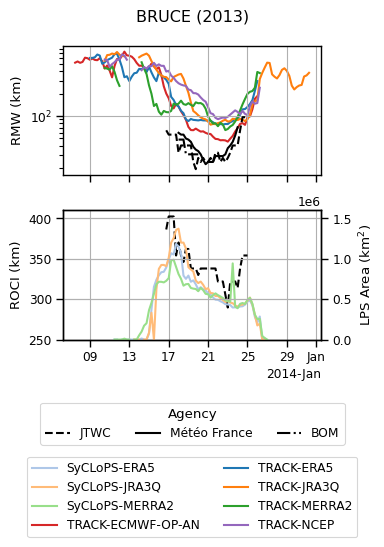

In [2]:
def plot_size(TRACK):
    fig, axs = plt.subplots(2, sharex = True, figsize = cm2inch([10,10]),)

    # RMW
    for s in TRACK.source.values:
        TRACK.sel(source = s).radius_max_wind_roll.plot(ax = axs[0], color = PALETTE[s], zorder = -1, lw = 1.5)
    TRACK.usa_rmw.plot(ax = axs[0], color = "k", linestyle = "--", label = "JTWC", lw = 1.5)
    TRACK.reunion_rmw.plot(ax = axs[0], color = "k", label = "Météo France", lw = 1.5)
    TRACK.bom_rmw.plot(ax = axs[0], color = "k", linestyle = "-.", label = "BOM", lw = 1.5)
    axs[0].set_ylabel("RMW (km)")
    axs[0].set_yscale("log")

    # ROCI
    TRACK.usa_roci.plot(ax = axs[1], color = "k", linestyle = "--", zorder = 100, lw = 1.5)
    axs[1].set_ylabel("ROCI (km)")

    # Size
    twinax = axs[1].twinx()
    for s in TRACK.source.values: 
        if s != "IBTrACS":
            line = TRACK.sel(source = s).lpsarea.plot(ax = twinax, color = PALETTE[s], lw = 1.5, label = s, zorder = 1)
    twinax.set_ylabel("LPS Area (km$^{2}$)")
    twinax.set_ylim(0)
    
    for ax in np.concat([axs, [twinax]]):
        ax.set_xlabel("")
        ax.set_title("")
        ax.grid()
        
    #axs[-1].xaxis.set_major_formatter(DateFormatter('%d/%m'))
    #axs[-1].set_xlabel("Sept. 2020", loc = "right")
    
    NAME = TRACK.name.values[0]
    SEASON = TRACK.time.dt.year.values[0]
    fig.suptitle(NAME + ' ('+str(SEASON)+')')
    plt.tight_layout()

    fig.legend(*axs[0].get_legend_handles_labels(), title = "Agency",
               loc = "outside lower center", ncol = 3, bbox_to_anchor = (0.5,-0.14))
    fig.legend(*twinax.get_legend_handles_labels(), title = "",
               loc = "outside upper center", ncol = 2, bbox_to_anchor = (0.5,-0.14))

    return fig, axs, twinax
    
b = "SI"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
NAME, SEASON = "BRUCE", 2013
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
fig, axs, twinax = plot_size(TRACK)
axs[-1].set_ylim(250,410)
twinax.set_ylim(0,1.6e6)

plt.savefig("size_info.png", bbox_inches = "tight")
plt.savefig("size_info.pdf", bbox_inches = "tight")